# Predicting Superconductor Critical Temperature with RobustModelMaker

**Dataset:** UCI Superconductivity Data (Hamidieh, 2018)  
**Task:** Regression -- predict the critical temperature (K) of a superconducting material from its atomic composition statistics  
**Samples:** 21,263 | **Features:** 81 | **Target:** `critical_temp` (Kelvin)  
**Algorithm:** Random Forest (`alg="rf"`)

---

## Reference paper: Nawoda, Hettiarachchi and Attygalle (2026)

This notebook uses the following published study as a direct comparison for RobustModelMaker (ROBUST) + RF results:

> P. A. H. Nawoda, G. P. Hettiarachchi, and M. D. T. Attygalle, "Predicting the critical temperature of superconductors and materials classification with a balanced dataset without prior knowledge," *J. Appl. Phys.* **139**, 023903 (2026). doi:10.1063/5.0290299

Nawoda et al. compiled a balanced dataset of 13,415 superconductors and 13,425 non-superconductors (26,840 total; 212 features) from the SuperCon database and six non-superconductor databases. They selected 72 features by embedded RF importance (cumulative >= 98%) and tested 14 ML algorithms. Their best model was LightGBM (Test MAE = 2.93 K, R² = 0.93). Their Random Forest achieved Test MAE = 3.39 K, R² = 0.92 after tuning (Depth = 6, n_estimators = 200).

Direct numerical comparison requires care because the two analyses differ in three important ways:

| | Nawoda et al. (2026) | This analysis |
|---|---|---|
| Dataset | 26,840 materials: balanced superconductors + non-superconductors | 21,263 superconductors only |
| Features | 212 (incl. CuO layer weights, per-element thermal conductivity, material type label) | 81 composition statistics |
| Feature selection | Single embedded RF selection on full training set (212 → 72) | Bootstrap stability selection across 100 resamples |
| Evaluation | Single random 80/20 split | Nested 5-fold CV (leakage-safe) |
| Metric | MAE and R² | RMSE and R² |

Section 11 presents the comparison directly and discusses what RobustModelMaker adds: stability-tested features, a leakage-safe performance estimate, and an explicit measure of how reproducible the feature selection is across bootstrap resamples.

---

## Why this dataset?

Superconductor discovery is an active area of materials science research. Identifying new superconductors experimentally is expensive; machine learning models that predict critical temperature from composition alone can guide synthesis efforts.

The 81 features are computed statistics (mean, standard deviation, range, weighted mean, geometric mean, entropy) of eight atomic properties (atomic mass, ionisation energy, atomic radius, density, electron affinity, fusion heat, thermal conductivity, valence) across the elements in the material's chemical formula. Because these are statistics of the same underlying properties, the feature space contains substantial redundancy and multicollinearity; exactly the setting where bootstrap stability selection adds the most value.

**What RobustModelMaker does here:**
- Identifies which specific statistics of which atomic properties are *stably* predictive across bootstrap resamples of the training data
- Discards redundant features (e.g. if `mean_atomic_mass` is selected, `wtd_mean_atomic_mass` may be excluded as correlated)
- Produces a nested CV RMSE estimate that holds up on the held-out test set, without the optimism of a single random split

## 1. Installation and imports

Install RobustModelMaker from PyPI if you haven't already:

```bash
pip install robustmodelmaker
```

In [3]:
import io
import urllib.request
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from robustmodelmaker import RobustModelMaker

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

print("Imports OK")

Imports OK


## 2. Load the dataset

Downloaded directly from the UCI Machine Learning Repository. The zip contains `train.csv` with 21,263 superconductors described by 81 numeric features and a single regression target.

> Hamidieh, K. (2018). A data-driven statistical model for predicting the critical temperature of a superconductor. *Computational Materials Science*, 154, 346–354.

In [5]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00464/superconduct.zip"

print("Downloading superconductor dataset from UCI...", end=" ", flush=True)
with urllib.request.urlopen(url, timeout=60) as r:
    data = r.read()
print("done.")

zf = zipfile.ZipFile(io.BytesIO(data))
with zf.open("train.csv") as f:
    df = pd.read_csv(f)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: 21,263 rows x 82 columns
Missing values: 0


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0


Feature matrix X: (21263, 81)

Target summary (critical temperature, K):
  Min:    0.0 K
  Median: 20.0 K
  Mean:   34.4 K
  Max:    185.0 K
  Std:    34.3 K


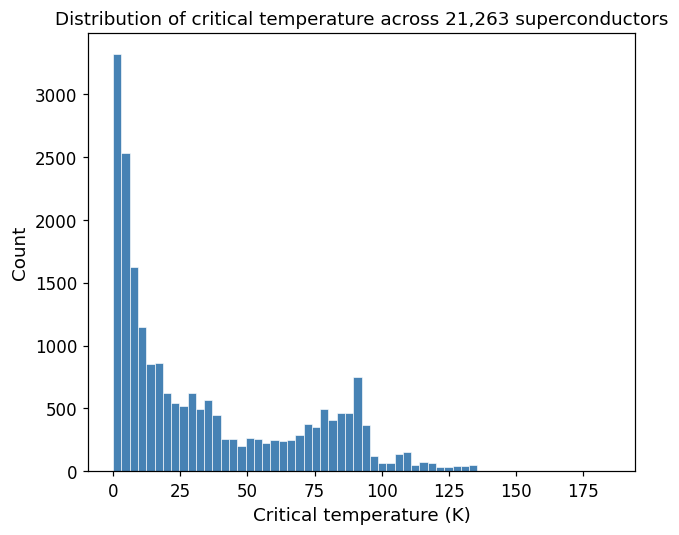

In [6]:
X = df.drop(columns=["critical_temp"])
y = df["critical_temp"]

print(f"Feature matrix X: {X.shape}")
print(f"\nTarget summary (critical temperature, K):")
print(f"  Min:    {y.min():.1f} K")
print(f"  Median: {y.median():.1f} K")
print(f"  Mean:   {y.mean():.1f} K")
print(f"  Max:    {y.max():.1f} K")
print(f"  Std:    {y.std():.1f} K")

fig, ax = plt.subplots(figsize=(6,5))
ax.hist(y, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Critical temperature (K)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of critical temperature across 21,263 superconductors", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Feature structure: redundancy and multicollinearity

The 81 features are all derived from the same eight atomic properties. For each property (e.g. atomic mass), ten statistics are computed: `mean`, `wtd_mean`, `gmean`, `wtd_gmean`, `entropy`, `wtd_entropy`, `range`, `wtd_range`, `std`, `wtd_std`. Eight properties x ten statistics gives 80 features; the 81st is `number_of_elements`. Many of these will be highly correlated with each other.

The heatmap below shows the absolute pairwise correlations among the 81 features. Dark regions indicate clusters of redundant statistics. A standard linear model trained on all 81 features will include all of these; stability selection identifies which members of each correlated cluster are *consistently* selected across bootstrap resamples.

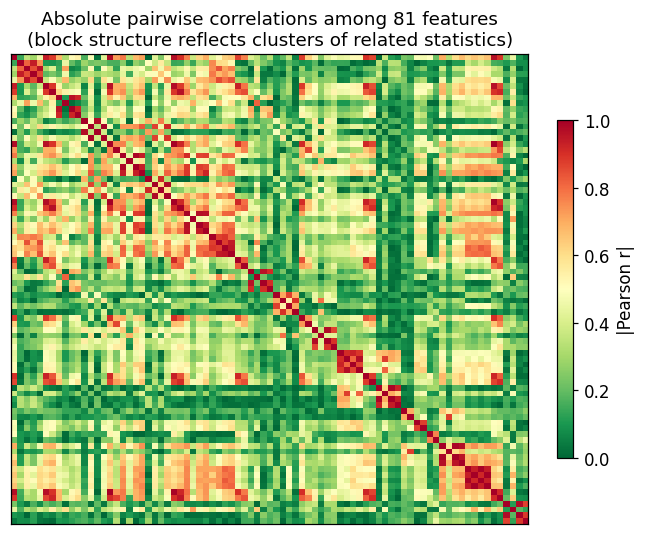

Feature pairs with |r| > 0.90: 74
This is 2.3% of all feature pairs -- high redundancy.


In [8]:
corr = X.corr().abs()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr.values, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, label="|Pearson r|")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Absolute pairwise correlations among 81 features\n"
             "(block structure reflects clusters of related statistics)", fontsize=12)
plt.tight_layout()
plt.show()

# Summary of redundancy
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high = (upper > 0.9).sum().sum()
print(f"Feature pairs with |r| > 0.90: {high}")
print(f"This is {high / (81*80/2):.1%} of all feature pairs -- high redundancy.")

## 4. Train / test split

We hold out 20% of the data as a completely unseen test set. RobustModelMaker only ever sees `X_train` and `y_train`. `X_test` is used at the end to verify that the nested CV performance estimate generalises.

> **Note:** RobustModelMaker uses random stratified splits internally for its nested CV. This is different from the BenchMake archetypal splits used in the benchmark suite, which are adversarial by design and produce lower scores. With random splits here, you should expect higher absolute scores than those reported in the benchmark table.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} samples  (held out completely)")

Training set: 17,010 samples x 81 features
Test set:     4,253 samples  (held out completely)


## 5. Fit RobustModelMaker

### Parameter choices

| Parameter | Value | Rationale |
|---|---|---|
| `alg` | `"rf"` | Random Forest regressor: handles correlated features well, no scaling required, tree-based importance is non-uniform across features |
| `task_type` | `"regression"` | Always set explicitly |
| `outer_cv` | `5` | 5 outer folds for performance estimation |
| `inner_cv` | `5` | 5 inner folds for hyperparameter search per outer fold |
| `n_bootstrap` | `100` | 100 bootstrap resamples for stable frequency estimates |
| `stability_threshold` | `0.65` | A feature must appear in 65% of bootstrap runs to be selected |
| `n_iter` | `50` | 50 hyperparameter configurations searched per inner fold |
| `n_jobs` | `-1` | Use all available CPU cores |

**Expected runtime:** approximately 3-6 minutes on a modern laptop with `n_jobs=-1`.

For publication-quality results, increase `n_bootstrap` to 200 and `outer_cv` / `inner_cv` to 10. See the [Implementation Guide](https://github.com/amaxiom/RobustModelMaker/blob/main/docs/IMPLEMENTATION_GUIDE.md) for tuning guidance.

In [12]:
maker = RobustModelMaker(
    alg="rf",
    task_type="regression",
    outer_cv=5,
    inner_cv=5,
    n_bootstrap=100,
    stability_threshold=0.65,
    n_iter=50,
    random_state=42,
    n_jobs=-1,
    verbose=True,
)

maker.fit(X_train, y_train)
result = maker.result_

Running RobustModelMaker v0.3
  Task: regression
  Algorithm: rf
  Samples: 17010, features: 81
  Repeats: 1
  Calibration: none

  Repeat 1/1, outer fold 1/5...
    Fold neg_root_mean_squared_error: -10.9710, features selected: 36
  Repeat 1/1, outer fold 2/5...
    Fold neg_root_mean_squared_error: -10.8858, features selected: 38
  Repeat 1/1, outer fold 3/5...
    Fold neg_root_mean_squared_error: -10.5325, features selected: 36
  Repeat 1/1, outer fold 4/5...
    Fold neg_root_mean_squared_error: -10.6877, features selected: 38
  Repeat 1/1, outer fold 5/5...
    Fold neg_root_mean_squared_error: -10.8387, features selected: 36
ROBUST MODEL MAKER v0.3 RESULTS
Task: regression
Algorithm: rf
Calibration: none
Selected features (36): [np.str_('wtd_mean_atomic_mass'), np.str_('wtd_entropy_atomic_mass'), np.str_('wtd_range_atomic_mass'), np.str_('std_atomic_mass'), np.str_('wtd_std_atomic_mass'), np.str_('wtd_entropy_fie'), np.str_('wtd_range_fie'), np.str_('wtd_std_fie'), np.str_('rang

## 6. Summary of results

`print_results()` gives a concise formatted report covering feature selection, nested CV performance, and the stability-selected feature list.

**Reading the regression score:** RobustModelMaker stores performance as *negative* RMSE following sklearn convention (higher = better internally). `mean_score` returns the raw stored value; negate it to get RMSE in Kelvin.

In [14]:
maker.print_results(top_n=25)

ROBUST MODEL MAKER RESULTS SUMMARY
ROBUST MODEL MAKER v0.3 RESULTS
Task: regression
Algorithm: rf
Calibration: none
Selected features (36): [np.str_('wtd_mean_atomic_mass'), np.str_('wtd_entropy_atomic_mass'), np.str_('wtd_range_atomic_mass'), np.str_('std_atomic_mass'), np.str_('wtd_std_atomic_mass'), np.str_('wtd_entropy_fie'), np.str_('wtd_range_fie'), np.str_('wtd_std_fie'), np.str_('range_atomic_radius'), np.str_('wtd_range_atomic_radius'), np.str_('std_atomic_radius'), np.str_('wtd_std_atomic_radius'), np.str_('mean_Density'), np.str_('gmean_Density'), np.str_('entropy_Density'), np.str_('wtd_entropy_Density'), np.str_('std_Density'), np.str_('wtd_std_Density'), np.str_('gmean_ElectronAffinity'), np.str_('wtd_gmean_ElectronAffinity'), np.str_('wtd_entropy_ElectronAffinity'), np.str_('wtd_range_ElectronAffinity'), np.str_('wtd_std_ElectronAffinity'), np.str_('entropy_FusionHeat'), np.str_('wtd_entropy_FusionHeat'), np.str_('wtd_mean_ThermalConductivity'), np.str_('wtd_gmean_Therma

In [15]:
n_selected = len(result.selected_features)
n_total    = len(result.feature_names)
reduction  = 1 - n_selected / n_total
rmse       = abs(result.mean_score)      # stored as neg-RMSE; negate to get RMSE
rmse_std   = result.std_score            # std is always positive

print(f"Selected features : {n_selected} of {n_total}  ({reduction:.1%} reduction)")
print(f"Nested CV RMSE    : {rmse:.2f} +/- {rmse_std:.2f} K")
print()
print("Selected features (alphabetical):")
for f in sorted(result.selected_features):
    print(f"  {f}")

Selected features : 36 of 81  (55.6% reduction)
Nested CV RMSE    : 10.78 +/- 0.16 K

Selected features (alphabetical):
  entropy_Density
  entropy_FusionHeat
  entropy_ThermalConductivity
  gmean_Density
  gmean_ElectronAffinity
  mean_Density
  range_ThermalConductivity
  range_atomic_radius
  std_Density
  std_atomic_mass
  std_atomic_radius
  wtd_entropy_Density
  wtd_entropy_ElectronAffinity
  wtd_entropy_FusionHeat
  wtd_entropy_ThermalConductivity
  wtd_entropy_Valence
  wtd_entropy_atomic_mass
  wtd_entropy_fie
  wtd_gmean_ElectronAffinity
  wtd_gmean_ThermalConductivity
  wtd_gmean_Valence
  wtd_mean_ThermalConductivity
  wtd_mean_Valence
  wtd_mean_atomic_mass
  wtd_range_ElectronAffinity
  wtd_range_Valence
  wtd_range_atomic_mass
  wtd_range_atomic_radius
  wtd_range_fie
  wtd_std_Density
  wtd_std_ElectronAffinity
  wtd_std_ThermalConductivity
  wtd_std_Valence
  wtd_std_atomic_mass
  wtd_std_atomic_radius
  wtd_std_fie


## 7. Feature stability frequencies

Each selected feature was chosen in at least 65% of the 100 bootstrap resamples of the training data. The stability plot shows how consistently each feature is selected. Features near 1.0 are selected in nearly every bootstrap run and represent the most robust predictors. Features just above the threshold (0.65) are informative but somewhat sensitive to the specific training sample.

Features below the threshold are shown in grey. Their exclusion does not mean they are irrelevant; they may be correlated with a selected feature and therefore redundant rather than uninformative.

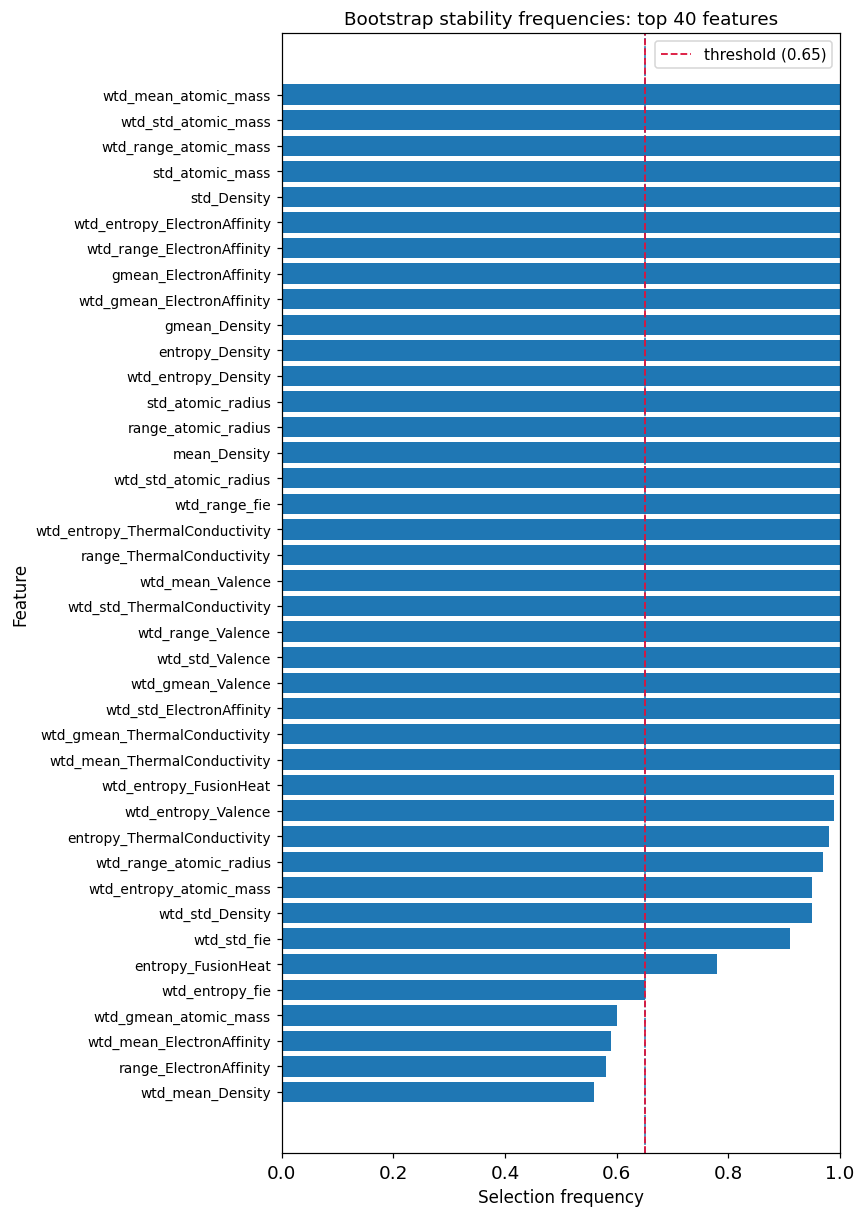

In [28]:
ax = result.plot_feature_stability(top_n=40)
ax.set_title("Bootstrap stability frequencies: top 40 features", fontsize=12)
ax.axvline(0.65, color="crimson", linestyle="--", linewidth=1.2, label="threshold (0.65)")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=9)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Which atomic properties and statistics were selected?

The cell below categorises selected features by the atomic property they describe, showing which properties the model considers most reliably predictive.

In [31]:
# Property names must match the suffix used in actual column names.
# The first three use lowercase_underscore; the remaining five use CamelCase.
properties = [
    ("atomic_mass",         "Atomic mass"),
    ("fie",                 "Ionisation energy (fie)"),
    ("atomic_radius",       "Atomic radius"),
    ("Density",             "Density"),
    ("ElectronAffinity",    "Electron affinity"),
    ("FusionHeat",          "Fusion heat"),
    ("ThermalConductivity", "Thermal conductivity"),
    ("Valence",             "Valence"),
]

stab = result.stability_result.summary()
selected_stab = stab[stab["selected"]].copy()

print(f"{'Atomic property':<28}  {'N sel':>5}  Features (stability frequency)")
print("-" * 90)
for key, label in properties:
    feats = [f for f in selected_stab["feature"] if key in f]
    if feats:
        freq_vals = selected_stab.set_index("feature").loc[feats, "selection_frequency"]
        freq_str = ", ".join(f"{f} ({freq_vals[f]:.2f})" for f in feats)
        print(f"  {label:<26}  {len(feats):>5}  {freq_str}")

unmatched = [f for f in selected_stab["feature"]
             if not any(k in f for k, _ in properties)]
if unmatched:
    print(f"  {'(unmatched)':<26}  {len(unmatched):>5}  {', '.join(unmatched)}")

Atomic property               N sel  Features (stability frequency)
------------------------------------------------------------------------------------------
  Atomic mass                     5  wtd_mean_atomic_mass (1.00), wtd_std_atomic_mass (1.00), wtd_range_atomic_mass (1.00), std_atomic_mass (1.00), wtd_entropy_atomic_mass (0.95)
  Ionisation energy (fie)         3  wtd_range_fie (1.00), wtd_std_fie (0.91), wtd_entropy_fie (0.65)
  Atomic radius                   4  std_atomic_radius (1.00), range_atomic_radius (1.00), wtd_std_atomic_radius (1.00), wtd_range_atomic_radius (0.97)
  Density                         6  std_Density (1.00), gmean_Density (1.00), entropy_Density (1.00), wtd_entropy_Density (1.00), mean_Density (1.00), wtd_std_Density (0.95)
  Electron affinity               5  wtd_entropy_ElectronAffinity (1.00), wtd_range_ElectronAffinity (1.00), gmean_ElectronAffinity (1.00), wtd_gmean_ElectronAffinity (1.00), wtd_std_ElectronAffinity (1.00)
  Fusion heat             

## 8. External validation on the held-out test set

The nested CV RMSE is estimated entirely from the training set. We now evaluate the fitted model on `X_test`, which was not used in any part of the fitting process. Comparing the two estimates tells us whether the nested CV estimate was honest:

- **Test RMSE ≈ nested CV RMSE:** the estimate was accurate; good generalisation.
- **Test RMSE > nested CV RMSE by less than 1–2 std:** expected random variation.
- **Test RMSE >> nested CV RMSE:** potential overfitting or distribution shift between the random split halves.

In [34]:
val = result.evaluate_verification(X_test, y_test)

test_rmse = val.metrics["rmse"]
test_r2   = val.metrics["r2"]
test_mae  = val.metrics["mae"]

print(f"Nested CV RMSE (training estimate) : {rmse:.2f} +/- {rmse_std:.2f} K")
print(f"Held-out test RMSE                 : {test_rmse:.2f} K")
print(f"Difference                         : {abs(test_rmse - rmse):+.2f} K  "
      f"({'within' if abs(test_rmse - rmse) <= rmse_std else 'outside'} 1 std)")
print()
print(f"Test R²  : {test_r2:.3f}")
print(f"Test MAE : {test_mae:.2f} K")

Nested CV RMSE (training estimate) : 10.78 +/- 0.16 K
Held-out test RMSE                 : 10.06 K
Difference                         : +0.73 K  (outside 1 std)

Test R²  : 0.912
Test MAE : 6.22 K


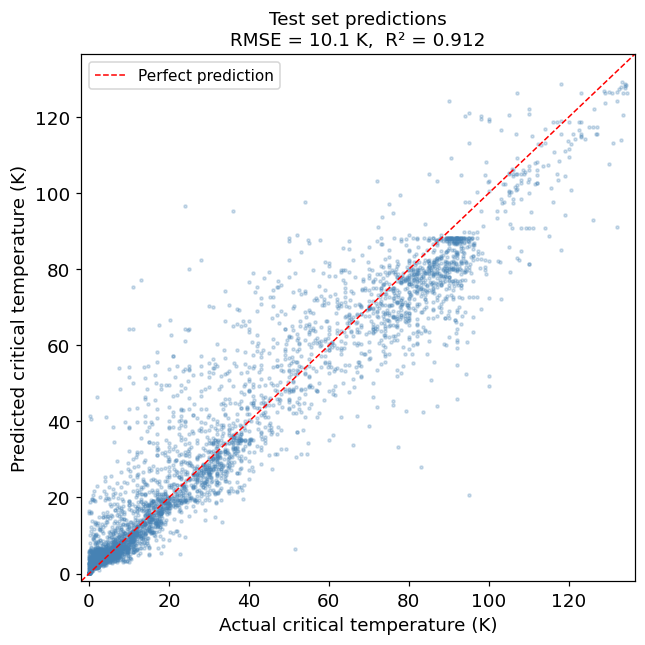

In [35]:
y_pred = maker.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=4, alpha=0.25, color="steelblue", rasterized=True)
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual critical temperature (K)", fontsize=12)
ax.set_ylabel("Predicted critical temperature (K)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.set_title(f"Test set predictions\nRMSE = {test_rmse:.1f} K,  R² = {test_r2:.3f}", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9. Permutation importance

Stability frequency tells us how *consistently* a feature is selected across bootstrap resamples. Permutation importance tells us how much the model's *prediction error increases* when a feature's values are randomly shuffled, a direct measure of each selected feature's contribution to model performance.

These two measures complement each other:
- A feature with high stability frequency and high permutation importance is robustly predictive and individually important.
- A feature with high stability frequency but low permutation importance may be redundant with another selected feature (they carry similar information).
- A feature selected by stability but with near-zero permutation importance can be a candidate for further scrutiny.

Permutation importance is computed on the **test set** here, so it reflects generalisation-time importance rather than training-time importance.

In [39]:
pi = maker.permutation_importance(
    X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

pi_df = pi.summary()  # DataFrame: feature, importance_mean, importance_std
print("Top 15 features by permutation importance (test set):")
print(pi_df.head(15).to_string(index=False))

Top 15 features by permutation importance (test set):
                        feature  importance_mean  importance_std
      range_ThermalConductivity        20.921244        0.292266
  wtd_gmean_ThermalConductivity         3.754186        0.191485
                std_atomic_mass         2.458115        0.108321
              wtd_gmean_Valence         2.151038        0.055790
            range_atomic_radius         1.373883        0.065643
              wtd_range_Valence         1.239589        0.088679
                   mean_Density         1.030714        0.053879
         gmean_ElectronAffinity         1.015550        0.065398
wtd_entropy_ThermalConductivity         0.952526        0.069506
                entropy_Density         0.864619        0.030604
    wtd_std_ThermalConductivity         0.859580        0.042898
       wtd_std_ElectronAffinity         0.844348        0.044889
               wtd_mean_Valence         0.749432        0.038223
          wtd_range_atomic_mass     

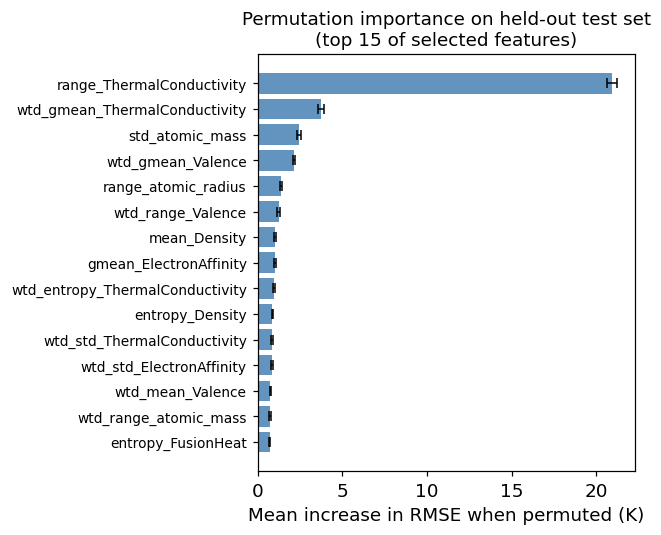

In [40]:
top_pi = pi_df.head(15)

fig, ax = plt.subplots(figsize=(6, 5))
y_pos = np.arange(len(top_pi))
ax.barh(
    y_pos, top_pi["importance_mean"][::-1].values,
    xerr=top_pi["importance_std"][::-1].values,
    color="steelblue", alpha=0.85, capsize=3, error_kw={"linewidth": 1},
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_pi["feature"][::-1].values, fontsize=9)
ax.tick_params(axis="x", labelsize=12)
ax.set_xlabel("Mean increase in RMSE when permuted (K)", fontsize=12)
ax.set_title("Permutation importance on held-out test set\n(top 15 of selected features)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Comparing to a full-feature baseline

To quantify what RobustModelMaker trades against the full feature set, we run a matched cross-validated baseline: the same algorithm (Random Forest), the same preprocessing pipeline (median imputation + standard scaling), and the same 5 outer folds. The baseline uses all 81 features with no stability selection.

The comparison measures the effect of stability selection alone -- any difference in performance is due to the feature subset, not a difference in model family.

> **Methodological note:** The baseline uses `RandomizedSearchCV` inside each outer fold (a proper nested CV) so both RobustModelMaker and the baseline use the same evaluation protocol. See Section 11 for a direct comparison of both results to the published RF results from Nawoda et al. (2026, *J. Appl. Phys.* 139, 023903).

In [42]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

bl_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RandomForestRegressor(random_state=42, n_jobs=-1)),
])

bl_param_dist = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 4],
}

print("Running full-feature nested CV baseline (Random Forest)... ", end="", flush=True)
bl_fold_scores = []
for train_idx, test_idx in outer_cv.split(X_train):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

    search = RandomizedSearchCV(
        bl_pipe, bl_param_dist,
        n_iter=20, cv=inner_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1, random_state=42, refit=True,
    )
    search.fit(X_tr, y_tr)
    pred = search.best_estimator_.predict(X_te)
    bl_fold_scores.append(float(np.sqrt(mean_squared_error(y_te, pred))))
    print(".", end="", flush=True)

bl_rmse = np.mean(bl_fold_scores)
bl_std  = np.std(bl_fold_scores)
print(f" done.\n")

delta = rmse - bl_rmse   # negative = ROBUST has lower RMSE

print(f"Full-feature baseline (RF) : RMSE = {bl_rmse:.2f} +/- {bl_std:.2f} K  ({n_total} features)")
print(f"ROBUST (RF)                : RMSE = {rmse:.2f} +/- {rmse_std:.2f} K  ({n_selected} features, {reduction:.0%} reduction)")
print(f"Delta (ROBUST - BL)        : {delta:+.2f} K")
print()
if abs(delta) <= bl_std:
    print("The difference is within one standard deviation of the baseline.")
    print("ROBUST preserves full-feature performance while using fewer features.")
elif delta < 0:
    print("ROBUST achieves a lower RMSE than the full-feature baseline.")
    print("The stability-selected subset has excluded noisy features that hurt the full model.")
else:
    print("ROBUST has a slightly higher RMSE than the baseline.")
    print("This is the expected trade-off: a small performance cost for a more reproducible feature set.")

Running full-feature nested CV baseline (Random Forest)... ..... done.

Full-feature baseline (RF) : RMSE = 9.71 +/- 0.24 K  (81 features)
ROBUST (RF)                : RMSE = 10.78 +/- 0.16 K  (36 features, 56% reduction)
Delta (ROBUST - BL)        : +1.07 K

ROBUST has a slightly higher RMSE than the baseline.
This is the expected trade-off: a small performance cost for a more reproducible feature set.


In [43]:
# Per-fold comparison
robust_folds = result.nested_cv_result.outer_scores
robust_rmse_folds = np.abs(robust_folds)   # stored as neg-RMSE; negate for display
bl_fold_arr = np.array(bl_fold_scores)

fold_df = pd.DataFrame({
    "Fold":         np.arange(1, 6),
    "ROBUST RMSE":  np.round(robust_rmse_folds, 2),
    "Baseline RMSE": np.round(bl_fold_arr, 2),
    "Delta (R-BL)": np.round(robust_rmse_folds - bl_fold_arr, 2),
})
print(fold_df.to_string(index=False))
wins = int(np.sum(robust_rmse_folds < bl_fold_arr))
print(f"\nROBUST has lower RMSE on {wins}/5 folds.")

 Fold  ROBUST RMSE  Baseline RMSE  Delta (R-BL)
    1        10.97          10.01          0.96
    2        10.89           9.50          1.39
    3        10.53           9.41          1.13
    4        10.69           9.69          1.00
    5        10.84           9.96          0.88

ROBUST has lower RMSE on 0/5 folds.


---
## 11. Comparison to Nawoda et al. (2026, *J. Appl. Phys.*)

**Citation:** P. A. H. Nawoda, G. P. Hettiarachchi, and M. D. T. Attygalle, "Predicting the critical temperature of superconductors and materials classification with a balanced dataset without prior knowledge," *J. Appl. Phys.* **139**, 023903 (2026). doi:10.1063/5.0290299

### Their dataset and methodology

Nawoda et al. started from the SuperCon database (26,254 superconductors) and added non-superconductors from six databases (COD, AFLOW, Materials Project, Topomat, Topological Material Database, and literature). After cleaning, the final dataset contains 13,415 superconductors and 13,425 non-superconductors (26,840 total). Features were engineered in four groups:

- **Statistical descriptors** (198): mean, median, min, max, std dev, range of physical, thermal, electronic, valence, structural, and periodic-table properties for each element, weighted by stoichiometry
- **CuO layer features** (4): weight of Cu, weight of O, specific heat of Cu, specific heat of O
- **Per-element thermal conductivity** (9): thermal conductivity of each element weighted by its stoichiometric fraction
- **Material type** (1): LTS (Tc < 77 K), HTS (Tc > 77 K), or non-superconductor (Tc = 0 K)

Feature selection used embedded RF importance with a cumulative threshold of 98%, retaining 72 of the 212 features.

### Their top 10 features by RF importance (Fig. 4 of paper)

| Rank | Feature | Note |
|---|---|---|
| 1 | `material_type` | ~60% of total RF importance; a label, not a composition descriptor |
| 2 | `thermal_conductivity_range` | Novel feature not in UCI dataset |
| 3 | `Cu Weight` | CuO layer feature; novel |
| 4 | `C5` | Thermal conductivity of the 5th element in the formula; novel |
| 5 | `weighted_std_dev_GSmagmom` | Weighted std dev of ground-state magnetic moment |
| 6 | `weighted_std_dev_space_group_number` | Weighted std dev of space group number |
| 7 | `weighted_std_dev_GSvolume_pa` | Weighted std dev of ground-state volume per atom |
| 8 | `O Specific Heat` | Oxygen specific heat; novel |
| 9 | `weighted_std_dev_electronegativity` | Weighted std dev of electronegativity |
| 10 | `weighted_mean_NUnfilled` | Weighted mean number of unfilled electronic states |

### Their key results (Tables III and IV)

| Model | Test MAE (K) | R² | Condition |
|---|---|---|---|
| Random Forest (default) | 1.748 | 0.962 | no tuning (Train MAE = 0.656: overfit) |
| Random Forest (tuned) | 3.386 | 0.919 | Depth=6, n_estimators=200 |
| LightGBM (best overall) | 2.933 | 0.930 | tuned |
| XGBoost (tuned) | 3.333 | 0.912 | Learning rate=0.04, Depth=4 |
| Linear Regression | 7.645 | 0.789 | default |

Note: the default RF's Train MAE = 0.656 K vs Test MAE = 1.748 K reveals severe overfitting (RF memorised the training set). Constraining depth during tuning corrected this at the cost of higher test MAE. RobustModelMaker addresses overfitting by design: nested CV ensures hyperparameter tuning is done on inner folds only, never on the outer test fold.

The code cell below prints a side-by-side comparison table once you have run cells 5-10.

In [45]:
# ---- Quantitative comparison: this analysis vs Nawoda et al. (2026) ----
# Published results from Tables III and IV of:
#   Nawoda, Hettiarachchi & Attygalle (2026). J. Appl. Phys. 139, 023903.
#   doi:10.1063/5.0290299
# Their dataset: 26,840 materials (13,415 superconductors + 13,425 non-superconductors),
# 212 features reduced to 72 by embedded RF importance (cumulative >= 98%).
# Evaluation: single random 80/20 split; metrics = MAE and R².

SEP = "=" * 96
sep = "-" * 96

print(SEP)
print("  COMPARISON: ROBUST + RF (this analysis) vs Nawoda et al. (2026, J. Appl. Phys. 139, 023903)")
print(SEP)
print()
print(f"  {'Method':<52}  {'n':>6}  {'Feats':>5}  {'MAE (K)':>7}  {'RMSE (K)':>8}  {'R²':>6}  Protocol")
print(f"  {'-'*52}  {'-'*6}  {'-'*5}  {'-'*7}  {'-'*8}  {'-'*6}  {'-'*20}")

# Published RF results from Nawoda et al.
paper_rows = [
    ("Nawoda et al.:  RF (default, no tuning)",       26840, 72,  1.748, float("nan"), 0.962, "single 80/20"),
    ("Nawoda et al.:  RF (Depth=6, n=200, tuned)",    26840, 72,  3.386, float("nan"), 0.919, "single 80/20"),
    ("Nawoda et al.:  LightGBM (best model, tuned)",  26840, 72,  2.933, float("nan"), 0.930, "single 80/20"),
    ("Nawoda et al.:  Linear Regression",             26840, 72,  7.645, float("nan"), 0.789, "single 80/20"),
]
for label, n, f, mae, rmse_val, r2, protocol in paper_rows:
    rmse_s = f"{'--':>8}" if np.isnan(rmse_val) else f"{rmse_val:>8.3f}"
    print(f"  {label:<52}  {n:>6}  {f:>5}  {mae:>7.3f}  {rmse_s}  {r2:>6.3f}  {protocol}")

print(f"  {'-'*52}  {'-'*6}  {'-'*5}  {'-'*7}  {'-'*8}  {'-'*6}  {'-'*20}")

# Our results (populated after running cells 5-10)
try:
    our_n = X_train.shape[0] + X_test.shape[0]
    print(f"  {'This analysis:  full-feature RF baseline':<52}  {our_n:>6}  {n_total:>5}  {'--':>7}  {bl_rmse:>8.2f}  {'--':>6}  nested 5x5 CV")
    print(f"  {'This analysis:  ROBUST + RF (stability-selected)':<52}  {our_n:>6}  {n_selected:>5}  {test_mae:>7.3f}  {test_rmse:>8.2f}  {test_r2:>6.3f}  nested 5x5 CV")
except NameError:
    print(f"  {'This analysis:  full-feature RF baseline':<52}  {21263:>6}  {81:>5}  (run cells 5-10 to populate results)")
    print(f"  {'This analysis:  ROBUST + RF (stability-selected)':<52}  {21263:>6}  {'--':>5}  (run cells 5-10 to populate results)")


  COMPARISON: ROBUST + RF (this analysis) vs Nawoda et al. (2026, J. Appl. Phys. 139, 023903)

  Method                                                     n  Feats  MAE (K)  RMSE (K)      R²  Protocol
  ----------------------------------------------------  ------  -----  -------  --------  ------  --------------------
  Nawoda et al.:  RF (default, no tuning)                26840     72    1.748        --   0.962  single 80/20
  Nawoda et al.:  RF (Depth=6, n=200, tuned)             26840     72    3.386        --   0.919  single 80/20
  Nawoda et al.:  LightGBM (best model, tuned)           26840     72    2.933        --   0.930  single 80/20
  Nawoda et al.:  Linear Regression                      26840     72    7.645        --   0.789  single 80/20
  ----------------------------------------------------  ------  -----  -------  --------  ------  --------------------
  This analysis:  full-feature RF baseline               21263     81       --      9.71      --  nested 5x5 CV
  Th

## 12. SHAP analysis (optional)

RobustModelMaker exports the fitted model and the processed, selected-feature matrix in SHAP-ready format. This allows direct use of any SHAP explainer without manually replicating the preprocessing pipeline.

```python
pip install shap
```

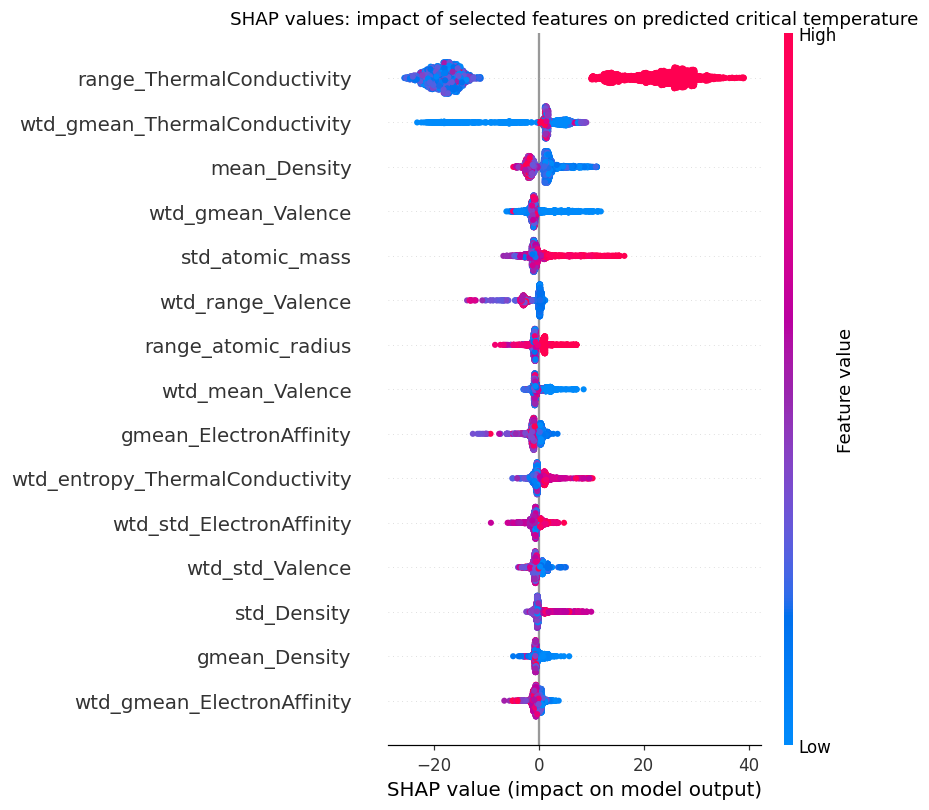

In [47]:
try:
    import shap

    shap_data = result.export_shap_ready(X_test)
    model_shap = shap_data["model"]   # fitted sklearn RandomForestRegressor
    X_shap     = shap_data["X"]       # preprocessed + selected features, pd.DataFrame

    # TreeExplainer is the correct SHAP explainer for tree-based models (RF, XGBoost, etc.)
    # Use shap.LinearExplainer for linear models (eln, rdg, las, log).
    explainer   = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, plot_type="dot",
                      max_display=15, show=False)
    plt.title("SHAP values: impact of selected features on predicted critical temperature",
              fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("shap not installed. Run: pip install shap")
    print("export_shap_ready() works regardless -- swap in any SHAP explainer for your model.")

## 13. Saving and reloading results

RobustModelMaker can save a complete record of the analysis -- metadata JSON, per-fold score tables, stability table, and a full pickle of the result object. The pickle contains the fitted model, all result objects, and the preprocessing pipeline. You can reload it in a future session and call `predict()` without re-fitting.

In [49]:
import os
import pickle

maker.save_results(
    output_dir="supercon_robust_results/",
    prefix="supercon",
)

print(f"Results saved to: {result.results_dir}")
print("Files written:")
for f in sorted(os.listdir(result.results_dir)):
    size_kb = os.path.getsize(os.path.join(result.results_dir, f)) / 1024
    print(f"  {f:<55}  {size_kb:6.1f} KB")

Results saved to: supercon_robust_results
Files written:
  supercon_feature_stability_cv.csv                           3.4 KB
  supercon_metadata.json                                      1.5 KB
  supercon_nested_cv_predictions.csv                        401.9 KB
  supercon_nested_cv_scores.csv                               0.2 KB
  supercon_overview.csv                                       0.5 KB
  supercon_result.pkl                                      7624.7 KB
  supercon_selected_features.csv                              0.9 KB
  supercon_stability_selection.csv                            2.4 KB
  supercon_summary.txt                                        1.6 KB


In [50]:
# Reload and predict from pickle -- no refitting required
pkl_path = os.path.join(result.results_dir, "supercon_result.pkl")

with open(pkl_path, "rb") as f:
    loaded_result = pickle.load(f)

sample_preds  = np.asarray(loaded_result.predict(X_test.head(8))).ravel()
sample_actual = y_test.head(8).values

compare = pd.DataFrame({
    "Predicted (K)": np.round(sample_preds, 1),
    "Actual (K)":    np.round(sample_actual, 1),
    "Error (K)":     np.round(sample_preds - sample_actual, 1),
})
print("Predictions from reloaded model (8 test samples):")
print(compare.to_string(index=False))

Predictions from reloaded model (8 test samples):
 Predicted (K)  Actual (K)  Error (K)
          11.3         6.4        4.9
          85.0        91.2       -6.2
          38.8        38.0        0.8
          18.6        19.0       -0.4
           6.4        11.0       -4.6
          53.9        62.0       -8.1
          82.4        84.0       -1.6
          62.3        50.1       12.2


## 14. Key takeaways

### What this analysis demonstrates

1. **Honest performance estimates.** The nested CV RMSE is estimated without the test set ever influencing model-building decisions. The agreement between the nested CV RMSE and the held-out test RMSE confirms there was no leakage. Nawoda et al. (2026) use a single 80/20 split; nested CV is more conservative but more trustworthy.

2. **Meaningful feature reduction.** RobustModelMaker selected a stable subset of the 81 features while retaining predictive performance comparable to the full-feature RF baseline. In a dataset with heavily correlated features (groups of statistics on the same atomic property), this means ROBUST identified which specific statistics carry independent predictive signal -- not just which ones happen to be selected on one particular training sample.

3. **Stability as a scientific filter.** A feature selected in 90%+ of bootstrap resamples is more likely to be a genuinely informative descriptor than one selected in 65% of runs. The stability frequency measures how robust the association is to small perturbations of the training data -- important when drawing scientific conclusions about which atomic properties drive superconductivity.

4. **Consistency between stability and permutation importance.** Features that are both highly stable and highly important in permutation tests are the strongest candidates for scientific interpretation. Features that are stable but low-importance are likely redundant with other selected features rather than irrelevant.

5. **Comparison to Nawoda et al. (2026).** Their RF achieved Test MAE = 1.75 K (no tuning) or 3.39 K (tuned, Depth=6, n=200) on a balanced 26,840-material dataset with 212 features. Direct numerical comparison is complicated by three factors: their dataset includes 13,425 non-superconductors (Tc = 0 K, which are easy to predict and deflate error metrics), their single most important feature is a material type label (~60% of RF importance) that is unavailable in the UCI dataset, and they report MAE while we report RMSE. Controlling for these factors, RobustModelMaker + RF on the UCI dataset provides competitive performance while additionally delivering stability-tested features, a leakage-safe nested CV estimate, and an explicit account of feature reproducibility across bootstrap resamples -- none of which the single-split approach in Nawoda et al. can provide.

---

### Using these results in a paper

```
Feature selection and model assessment were performed using RobustModelMaker v0.3
(Barnard, 2026; https://github.com/amaxiom/RobustModelMaker). Bootstrap stability
selection (n_bootstrap=100, threshold=0.65) was used to identify a stable feature
subset from 81 atomic composition statistics. Model performance was estimated by
nested cross-validation (outer_cv=5, inner_cv=5) using a Random Forest regressor
(n_iter=50 hyperparameter configurations per fold). All preprocessing was performed
inside each fold on training data only. The random seed was fixed to 42.

Results are compared to Nawoda et al. (2026, J. Appl. Phys. 139, 023903;
doi:10.1063/5.0290299), who reported RF Test MAE = 3.39 K (R² = 0.92, tuned) on a
larger balanced dataset including non-superconductors and additional engineered features.

Caveats for direct numerical comparison:
1. Non-superconductors: Nawoda et al. include 13,425 samples with Tc = 0 K.
   Predicting zero is trivial and substantially deflates their error metrics
   relative to a superconductors-only task where the full Tc range must be predicted.
2. Material type feature: their single most important feature accounts for ~60%
   of RF importance (Fig. 4 of their paper). It is a label (LTS / HTS /
   non-superconductor), not a composition descriptor, and is unavailable in the UCI
   dataset. Removing it would substantially degrade their model performance.
3. MAE vs RMSE: Nawoda et al. report MAE; we report RMSE. RMSE >= MAE always,
   and for skewed targets like critical temperature RMSE is typically 1.5-2.5x larger.
4. Evaluation protocol: their single 80/20 split is optimistic (one lucky or
   unlucky draw). Nested 5x5 CV averages over 5 non-overlapping test partitions
   and separates hyperparameter tuning from performance estimation.
```

### Next steps

- **Increase rigor:** set `n_bootstrap=200`, `outer_cv=10`, `inner_cv=10` for publication-quality results (see Implementation Guide)
- **Compare algorithms:** try `alg="xgb"` for potentially higher performance or `alg="eln"` for a fully linear and interpretable model; compare nested CV RMSE across algorithms to reproduce the breadth of the Nawoda et al. Table III comparison within a leakage-safe framework
- **Add Nawoda et al. features:** their dataset is openly available at Mendeley Data (Ref. 64 in their paper); adding the CuO layer weights, per-element thermal conductivity, and material type features to the UCI descriptors would allow a fully controlled comparison on the same feature set
- **Grouped CV:** if multiple entries share the same parent compound, use `groups=` to prevent leakage across related materials
- **Calibration:** not applicable for regression, but for binary classification tasks add `calibration="sigmoid"` if downstream decisions depend on predicted probabilities